## Heart Disease Risk Analysis

Cardiovascular diseases (CVDs) are the first cause of deaths worldwide, taking nearly 17.9M lives each year which represent 31% of global deaths. 4 of 5 deaths by CVDs are due to heart attacks and cardiovascular accidents and a third of it on people under 70 years old. Heart failure are commonly caused by CVDs and this dataset contained 11 features used to predict a posible heart disease.

People with CVDs o high cardiovascular risk (diabetes, high blood pressure, hyperlipidemia or preexisting condition) require early detection and management where a machine learning model can be helpfull.

Content
1. Age: Pacient age [years]
2. Sex = M: Male, 
         F: Female
3. ChestPainType =  TA: Typical Angina, 
                    ATA: Atypical Angina, 
                    NAP: Non-Anginal Pain, 
                    ASY: Asymptomatic
4. RestingBP: Resting Blood Presure [mm Hg]
5. Cholesterol [mm/dl]
6. FastingBS: Fasting Blood Sugar [1: if FastingBS > 120 mg/dl, 0: other case]
7. RestingECG: Resting Electrocardiogram [Normal: Normal, ST: Strain Pattern, LVH: Left Ventricular Hypertrophy]
8. MaxHR: Max Heart Rate [Numeric value between 60 y 202]
9. ExerciseAngina: Angina induce by exercise [Y: Yes, N: No]
10. Oldpeak: Numeric value of the degree of exercise-induced ST segment depression relative to rest
11. ST_Slope: Slope segment ST of max exercise [Up, Flat, Down]
12. HeartDisease: target [1: cardiopathy, 0: Normal]

In [34]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\usuario\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1


In [35]:
#Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [36]:
# Data load
df = pd.read_csv("heart_2.csv")
df.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1


## Data Understanding

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [38]:
print(f'\nDuplicated: {df.duplicated().sum()}\n')


Duplicated: 0



In [39]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [40]:
(pd.DataFrame({
    "Condition": ["Cholesterol = 0", "RestingBP = 0", "Oldpeak < 0"],
    "Percentage": [
        (df["Cholesterol"]==0).mean()*100,
        (df["RestingBP"]==0).mean()*100,
        (df["Oldpeak"]<0).mean()*100
    ]
}).round(2))

,Condition,Percentage
0,Cholesterol = 0,18.74
1,RestingBP = 0,0.11
2,Oldpeak < 0,1.42


## Data Cleaning

In [41]:
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df = df.dropna(subset=["RestingBP"])
df = df[df["Oldpeak"]>=0]

In [42]:
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["Cholesterol"] = df["Cholesterol"].fillna(df['Cholesterol'].median())

In [43]:
categoric_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "FastingBS"]
for col in categoric_cols:
    print(f"{col}: {df[col].unique()}")

Sex: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType: <ArrowStringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingECG: <ArrowStringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
ExerciseAngina: <ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str
ST_Slope: <ArrowStringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str
FastingBS: [0 1]


In [44]:
df["Sex"] = df["Sex"].map({
    "M": "Male",
    "F": "Female"})

df["FastingBS"] = df["FastingBS"].map({
    0: "< 120 [mg/dL]",
    1: ">= 120 [mg/dL]"})

df["HeartDisease_label"] = df["HeartDisease"].map({
    0: "Normal",
    1: "Cardiopathy"})

In [45]:
# Final check
print(df.isnull().sum())

Age                   0
Sex                   0
ChestPainType         0
RestingBP             0
Cholesterol           0
FastingBS             0
RestingECG            0
MaxHR                 0
ExerciseAngina        0
Oldpeak               0
ST_Slope              0
HeartDisease          0
HeartDisease_label    0
dtype: int64


In [46]:
df.sample(5).T

,522,107,493,211,624
Age,50,34,51,50,63
Sex,Male,Male,Male,Female,Female
ChestPainType,ASY,ATA,NAP,NAP,ASY
RestingBP,144.0,150.0,137.0,140.0,150.0
Cholesterol,349.0,214.0,339.0,288.0,407.0
FastingBS,< 120 [mg/dL],< 120 [mg/dL],< 120 [mg/dL],< 120 [mg/dL],< 120 [mg/dL]
RestingECG,LVH,ST,Normal,Normal,LVH
MaxHR,120,168,127,140,154
ExerciseAngina,Y,N,Y,Y,N
Oldpeak,1.0,0.0,1.7,0.0,4.0


Values equal to 0 in _RestingBP_ and negative values in _Oldpeak_ are considered inconsistent with their clinical definitions and likely correspond to data entry or measurement errors. Given their very low proportion in the dataset (0.1% and 1.4%, respectively), these observations were removed, as their impact on the overall distribution is negligible.

In contrast, approximately 19% of the values in _Cholesterol_ are equal to 0. Removing these observations would significantly reduce the dataset and potentially introduce bias. Therefore, these values were treated as missing and imputed using the median, which is robust to outliers. The unusually high proportion of zero values in _Cholesterol_ suggests a potential systematic recording issue or placeholder value, rather than true physiological measurements.

After the cleaning there is no null or empty data.

In [47]:
# Save
df.to_csv("heart_cleaned.csv", index=False)

## Univariate Exploratory Data Analysis (EDA)

### Cholesterol

In [48]:
display(df["Cholesterol"].describe())
print(f"\nSkewness: {stats.skew(df["Cholesterol"]):.2f}")
print(f"Kurtosis: {stats.kurtosis(df["Cholesterol"]):.2f}")
print(f"Coefficient of variation: {(df["Cholesterol"].std() / df["Cholesterol"].mean()) * 100:.2f}%")

count    904.000000
mean     243.384956
std       53.738632
min       85.000000
25%      214.000000
50%      237.000000
75%      268.000000
max      603.000000
Name: Cholesterol, dtype: float64


Skewness: 1.43
Kurtosis: 6.19
Coefficient of variation: 22.08%


In [49]:
# Atypical values
Q1 = df["Cholesterol"].quantile(0.25)
Q3 = df["Cholesterol"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Cholesterol"] < lower_bound) | (df["Cholesterol"] > upper_bound)]["Cholesterol"]

print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 39 (4.31%)


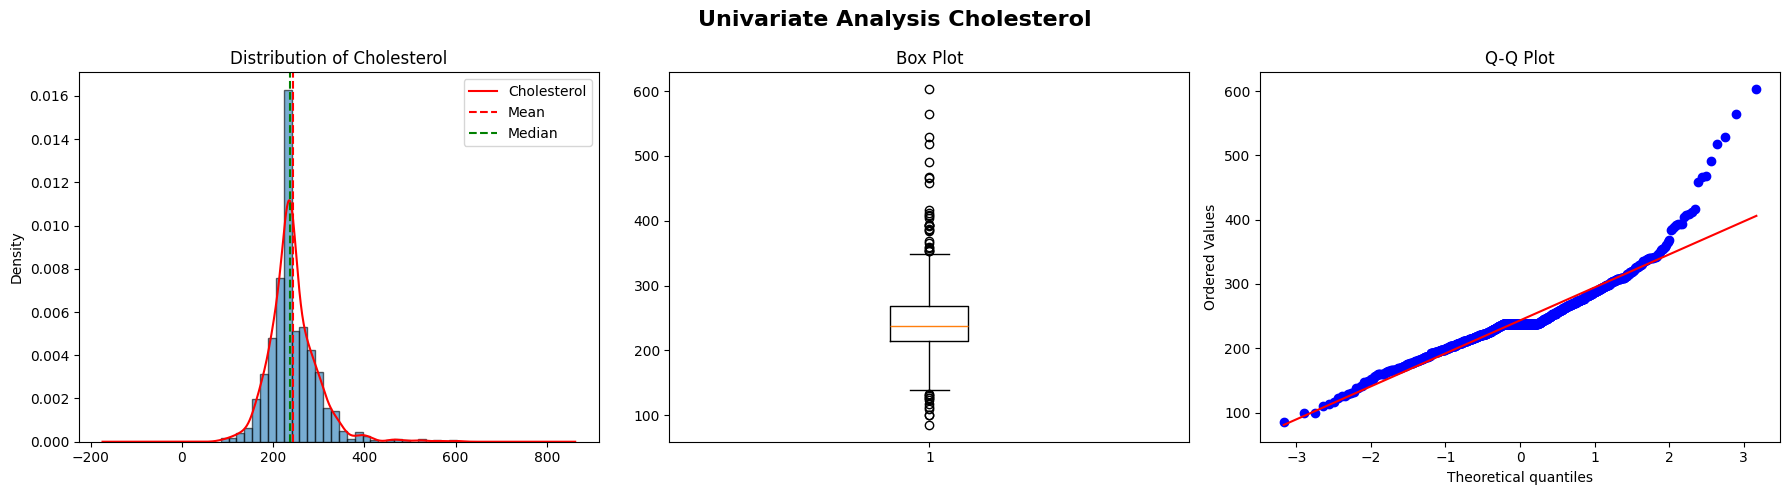

In [50]:
# Visual distribution of Cholesterol
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis Cholesterol', fontsize=16, fontweight='bold')

# Hist + KDE
axes[0].hist(df["Cholesterol"], bins=30, density=True, alpha=0.6, edgecolor="black")
df["Cholesterol"].plot(kind="density", ax=axes[0], color="red")

mean = df["Cholesterol"].mean()
median = df["Cholesterol"].median()

axes[0].axvline(mean, color="red", linestyle="--", label="Mean")
axes[0].axvline(median, color="green", linestyle="--", label="Median")
axes[0].legend()
axes[0].set_title("Distribution of Cholesterol")

# Box plot
axes[1].boxplot(df["Cholesterol"], vert=True)
axes[1].set_title("Box Plot")

# Q-Q Plot
stats.probplot(df["Cholesterol"], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [51]:
from scipy.stats import shapiro, normaltest

# Clean Dataframe
data = df["Cholesterol"]

# H0: Normal distribution.
# Ha: Non Normal distribution.

shapiro_stat, shapiro_p = shapiro(data)
dag_stat, dag_p = normaltest(data)

print(f"Shapiro-Wilk: statistic value = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
print(f"D'Agostino-Pearson: statistic value = {dag_stat:.4f}, p-value = {dag_p:.4f}")

Shapiro-Wilk: statistic value = 0.9092, p-value = 0.0000
D'Agostino-Pearson: statistic value = 307.0264, p-value = 0.0000


#### Insights
- _Cholesterol_ exhibits a right-skewed distribution, with a long tail towards higher values.
- The presence of outliers is confirmed by the boxplot and IQR method (~4.3% of outliers).
- The mean is higher than the median, reinforcing the presence of positive skewness.
- The Q-Q plot shows clear deviations from normality, particularly in the upper quantiles.
#### Statistical Test
- Both Shapiro-Wilk and D’Agostino-Pearson tests reject the null hypothesis of normality (p < 0.05), confirming that the distribution is not Gaussian.
#### Interpretation
- The distribution suggests the presence of individuals with significantly higher cholesterol levels, which may correspond to higher cardiovascular risk.
#### Modeling Implications
- Parametric models assuming normality may be affected.
- Transformations (e.g., log) could be explored.
- Tree-based models are more robust to skewness and outliers.
- Outliers may contain valuable information and should not be removed without strong justification.

### Oldpeak

In [52]:
display(df["Oldpeak"].describe())
print(f"\nSkewness: {stats.skew(df["Oldpeak"]):.2f}")
print(f"Kurtosis: {stats.kurtosis(df["Oldpeak"]):.2f}")
print(f"Coefficient of variation: {(df["Oldpeak"].std() / df["Oldpeak"].mean()) * 100:.2f}%")

count    904.000000
mean       0.913606
std        1.047342
min        0.000000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64


Skewness: 1.14
Kurtosis: 1.16
Coefficient of variation: 114.64%


In [53]:
# Atypical values
Q1 = df["Oldpeak"].quantile(0.25)
Q3 = df["Oldpeak"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Oldpeak"] < lower_bound) | (df["Oldpeak"] > upper_bound)]["Oldpeak"]

print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 15 (1.66%)


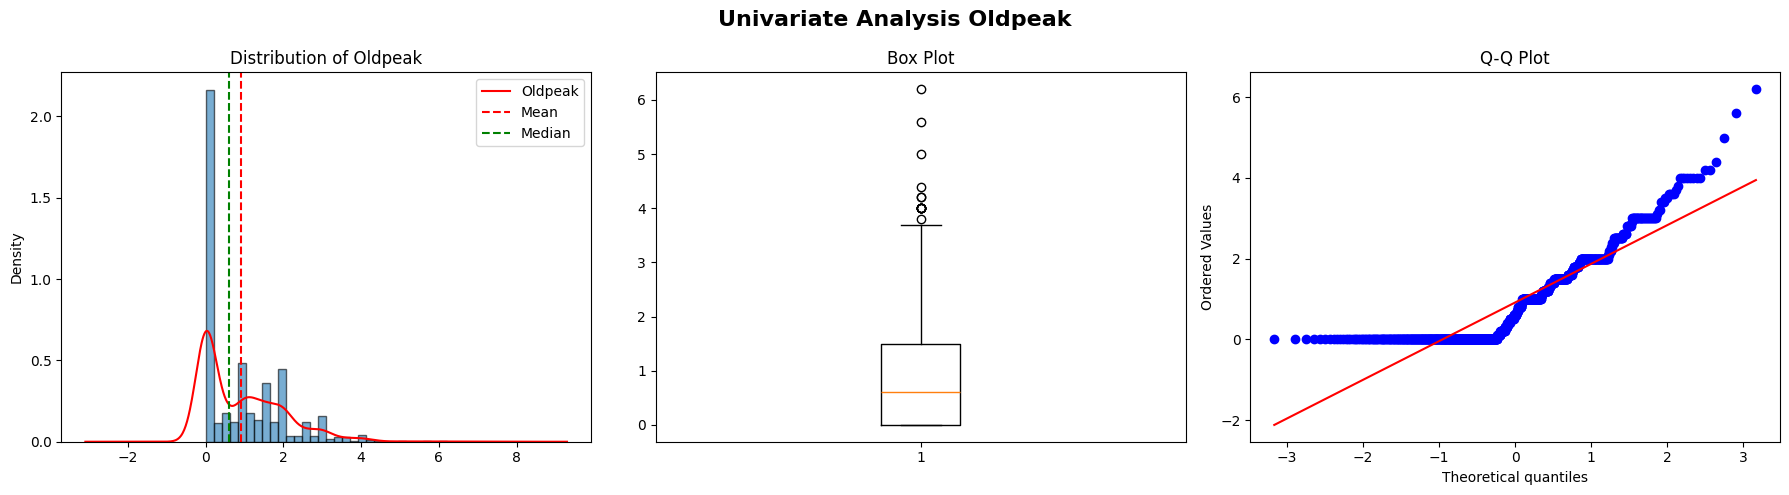

In [54]:
# Visual distribution of Oldpeak
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis Oldpeak', fontsize=16, fontweight='bold')

# Hist + KDE
axes[0].hist(df["Oldpeak"], bins=30, density=True, alpha=0.6, edgecolor="black")
df["Oldpeak"].plot(kind="density", ax=axes[0], color="red")

mean = df["Oldpeak"].mean()
median = df["Oldpeak"].median()

axes[0].axvline(mean, color="red", linestyle="--", label="Mean")
axes[0].axvline(median, color="green", linestyle="--", label="Median")
axes[0].legend()
axes[0].set_title("Distribution of Oldpeak")

# Box plot
axes[1].boxplot(df["Oldpeak"], vert=True)
axes[1].set_title("Box Plot")

# Q-Q Plot
stats.probplot(df["Oldpeak"], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [55]:
from scipy.stats import shapiro, normaltest

# Clean Dataframe
data = df["Oldpeak"]

# H0: Normal distribution.
# Ha: Non Normal distribution.

shapiro_stat, shapiro_p = shapiro(data)
dag_stat, dag_p = normaltest(data)

print(f"Shapiro-Wilk: statistic value = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
print(f"D'Agostino-Pearson: statistic value = {dag_stat:.4f}, p-value = {dag_p:.4f}")

Shapiro-Wilk: statistic value = 0.8313, p-value = 0.0000
D'Agostino-Pearson: statistic value = 155.7216, p-value = 0.0000


#### Insights
- _Oldpeak_ exhibits a right-skewed distribution, with a long tail towards highers values.
- The presence of outliers is confirmed by the boxplot and IQR method (~1.7% of outliers).
- The mean is higher than the median, reinforcing the presence of positive skewness.
- The Q-Q plot shows clear deviations from normality, particularly in the extremes.
#### Statistical Test
- Both Shapiro-Wilk and D’Agostino-Pearson tests reject the null hypothesis of normality (p < 0.05), confirming that the distribution is not Gaussian.
#### Interpretation
- From a clinical perspective, higher values of *Oldpeak* are generally associated with exercise-induced ST depression, which may indicate myocardial ischemia. In the context of this dataset, the presence of extreme values is consistent with the right-skewed distribution observed in the univariate analysis.Therefore, these high values are not treated as noise or errors, but rather as potentially informative observations that may represent higher cardiovascular risk.
#### Modeling Implication
- Extreme values in *Oldpeak* should be preserved, as they may contribute significantly to the predictive power of the model.

### Resting BP

In [56]:
display(df["RestingBP"].describe())
print(f"\nSkewness: {stats.skew(df["RestingBP"]):.2f}")
print(f"Kurtosis: {stats.kurtosis(df["RestingBP"]):.2f}")
print(f"Coefficient of variation: {(df["RestingBP"].std() / df["RestingBP"].mean()) * 100:.2f}%")

count    904.000000
mean     132.806416
std       17.952414
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64


Skewness: 0.60
Kurtosis: 0.79
Coefficient of variation: 13.52%


In [57]:
# Atypical values
Q1 = df["RestingBP"].quantile(0.25)
Q3 = df["RestingBP"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["RestingBP"] < lower_bound) | (df["RestingBP"] > upper_bound)]["RestingBP"]

print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 27 (2.99%)


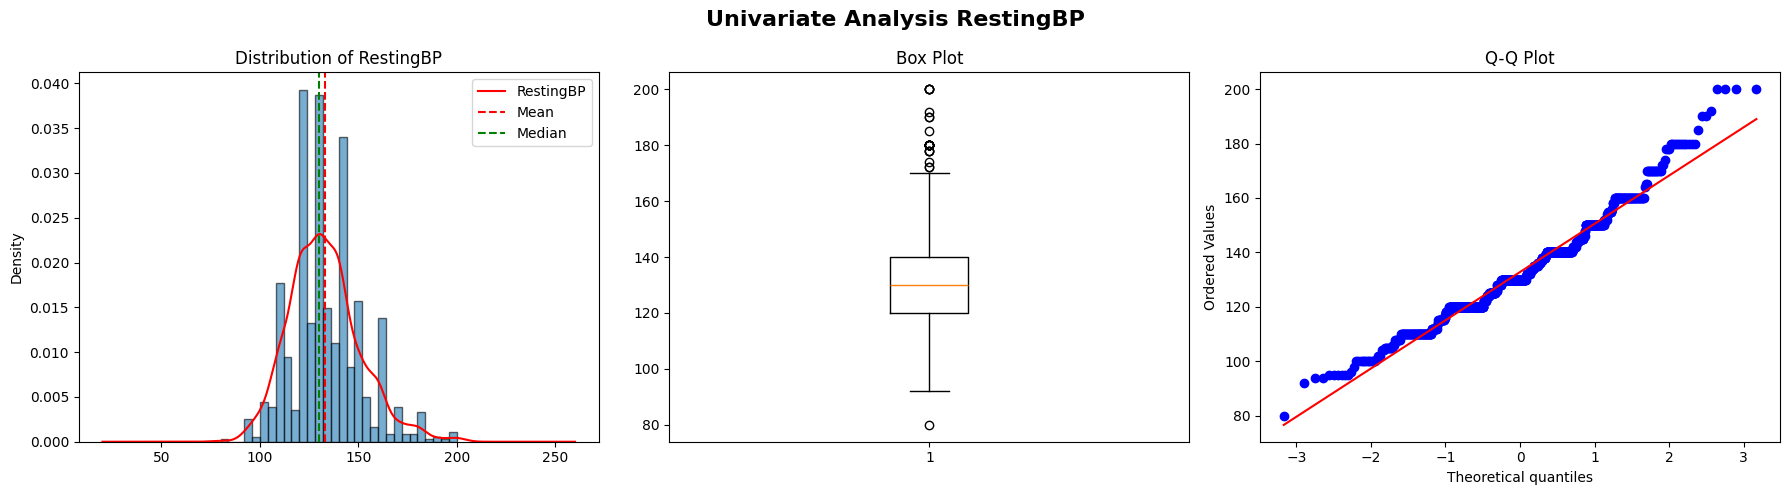

In [58]:
# Visual distribution of RestingBP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis RestingBP', fontsize=16, fontweight='bold')

# Hist + KDE
axes[0].hist(df["RestingBP"], bins=30, density=True, alpha=0.6, edgecolor="black")
df["RestingBP"].plot(kind="density", ax=axes[0], color="red")

mean = df["RestingBP"].mean()
median = df["RestingBP"].median()

axes[0].axvline(mean, color="red", linestyle="--", label="Mean")
axes[0].axvline(median, color="green", linestyle="--", label="Median")
axes[0].legend()
axes[0].set_title("Distribution of RestingBP")

# Box plot
axes[1].boxplot(df["RestingBP"], vert=True)
axes[1].set_title("Box Plot")

# Q-Q Plot
stats.probplot(df["RestingBP"], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [59]:
from scipy.stats import shapiro, normaltest

# Clean Dataframe
data = df["RestingBP"]

# H0: Normal distribution.
# Ha: Non Normal distribution.

shapiro_stat, shapiro_p = shapiro(data)
dag_stat, dag_p = normaltest(data)

print(f"Shapiro-Wilk: statistic value = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
print(f"D'Agostino-Pearson: statistic value = {dag_stat:.4f}, p-value = {dag_p:.4f}")

Shapiro-Wilk: statistic value = 0.9712, p-value = 0.0000
D'Agostino-Pearson: statistic value = 61.9652, p-value = 0.0000


#### Insights
- _RestingBP_ exhibits a right-skewed distribution, with a long tail towards highers values.
- The presence of outliers is confirmed by the boxplot and IQR method (~3% of outliers).
- The mean is higher than the median, reinforcing the presence of positive skewness.
- The Q-Q plot shows clear deviations from normality, particularly in the upper quantiles.
#### Statistical Test
- Both Shapiro-Wilk and D’Agostino-Pearson tests reject the null hypothesis of normality (p < 0.05), confirming that the distribution is not Gaussian.
#### Interpretation
- The distribution suggests the presence of individuals with significantly higher blood pressure, which may correspond to higher cardiovascular risk.
#### Modeling Implication
- Parametric models assuming normality may be affected.
- Transformations (e.g., log) could be explored.
- Tree-based models are more robust to skewness and outliers.
- Outliers may contain valuable information and should not be removed without strong justification.

### Age and MaxHR

,Age,MaxHR
count,904.000000,904.000000
mean,53.528761,136.969027
std,9.431648,25.337263
min,28.000000,60.000000
25%,47.000000,120.000000
50%,54.000000,138.000000
75%,60.000000,156.000000
max,77.000000,202.000000


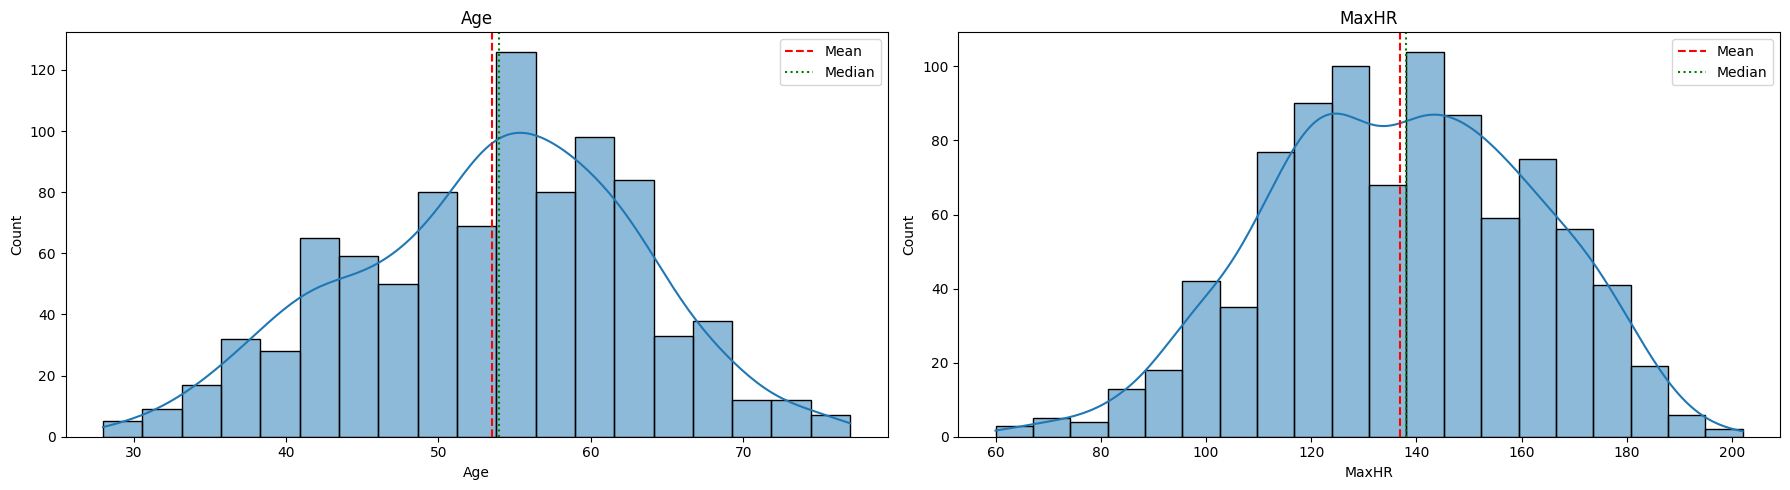

In [60]:
numeric_columns = ["Age", "MaxHR"]
display(df[numeric_columns].describe())

fig, axes = plt.subplots(1, 2, figsize=(18,5))

for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    
    mean = df[col].mean()
    median = df[col].median()
    
    axes[i].axvline(mean, color="red", linestyle='--', label='Mean')
    axes[i].axvline(median, color="green", linestyle=':', label='Median')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [61]:
# Atypical values
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    print(f"Outliers {col}: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Outliers Age: 0 (0.00%)
Outliers MaxHR: 2 (0.22%)


Age and MaxHR shows a relatively symmetric distribution, with mean and median closely aligned, indicating low skewness.

For MaxHR a small number of extreme values (~0.22%) are present; however, given their minimal proportion and the overall stability of the distribution, they are not considered problematic.

These values are therefore retained, as they are unlikely to significantly impact model performance.

### Insights on Outliers
- Extreme values in *Cholesterol* may correspond to individuals with unusually high cholesterol levels, which are commonly associated with increased cardiovascular risk. These observations are therefore considered potentially informative rather than noise.
- Extreme values in *Oldpeak* may reflect higher levels of ST depression during exercise, which in a clinical context is associated with myocardial ischemia. Given the right-skewed distribution observed, these values are retained as they may enhance the predictive power of the model.
- Extreme values in *RestingBP* may correspond to individuals with unusually high blood pressure, which are commonly associated with increased cardiovascular risk. These observations are therefore considered potentially informative rather than noise.
- In all cases, extreme values are preserved, as they are more likely to represent meaningful variability related to cardiovascular risk rather than data errors.

### Target: Heart Disease

HeartDisease
1    498
0    406
Name: count, dtype: int64

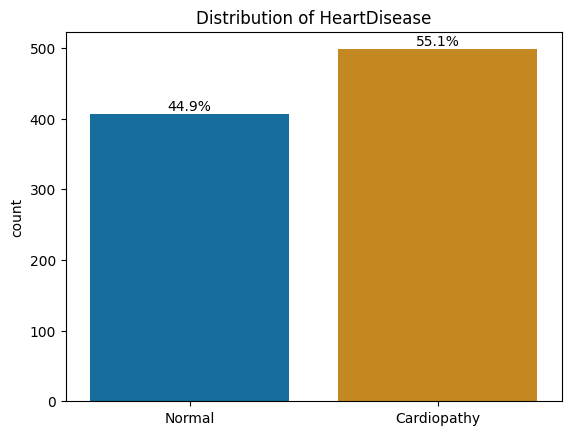

In [62]:
display(df["HeartDisease"].value_counts())
sns.countplot(x="HeartDisease_label", data=df, 
              hue="HeartDisease_label", palette="colorblind",
              legend=False)


total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.text(x, y + 5, percentage, ha='center')

plt.xlabel(None)
plt.title("Distribution of HeartDisease")
plt.show()

The target variable shows a relatively balanced distribution between the two classes.

- Class Normal: ~45%
- Class Cardiopathy: ~55%

Although there is a slight predominance of positive cases, the dataset does not present a severe class imbalance.

#### Implications

- The relatively balanced distribution allows the use of standard evaluation metrics such as accuracy.
- However, given the medical context, additional metrics such as precision, recall, and ROC-AUC should still be considered.
- False negatives (predicting no disease when it exists) could be particularly critical in this scenario.

## Bivariate EDA

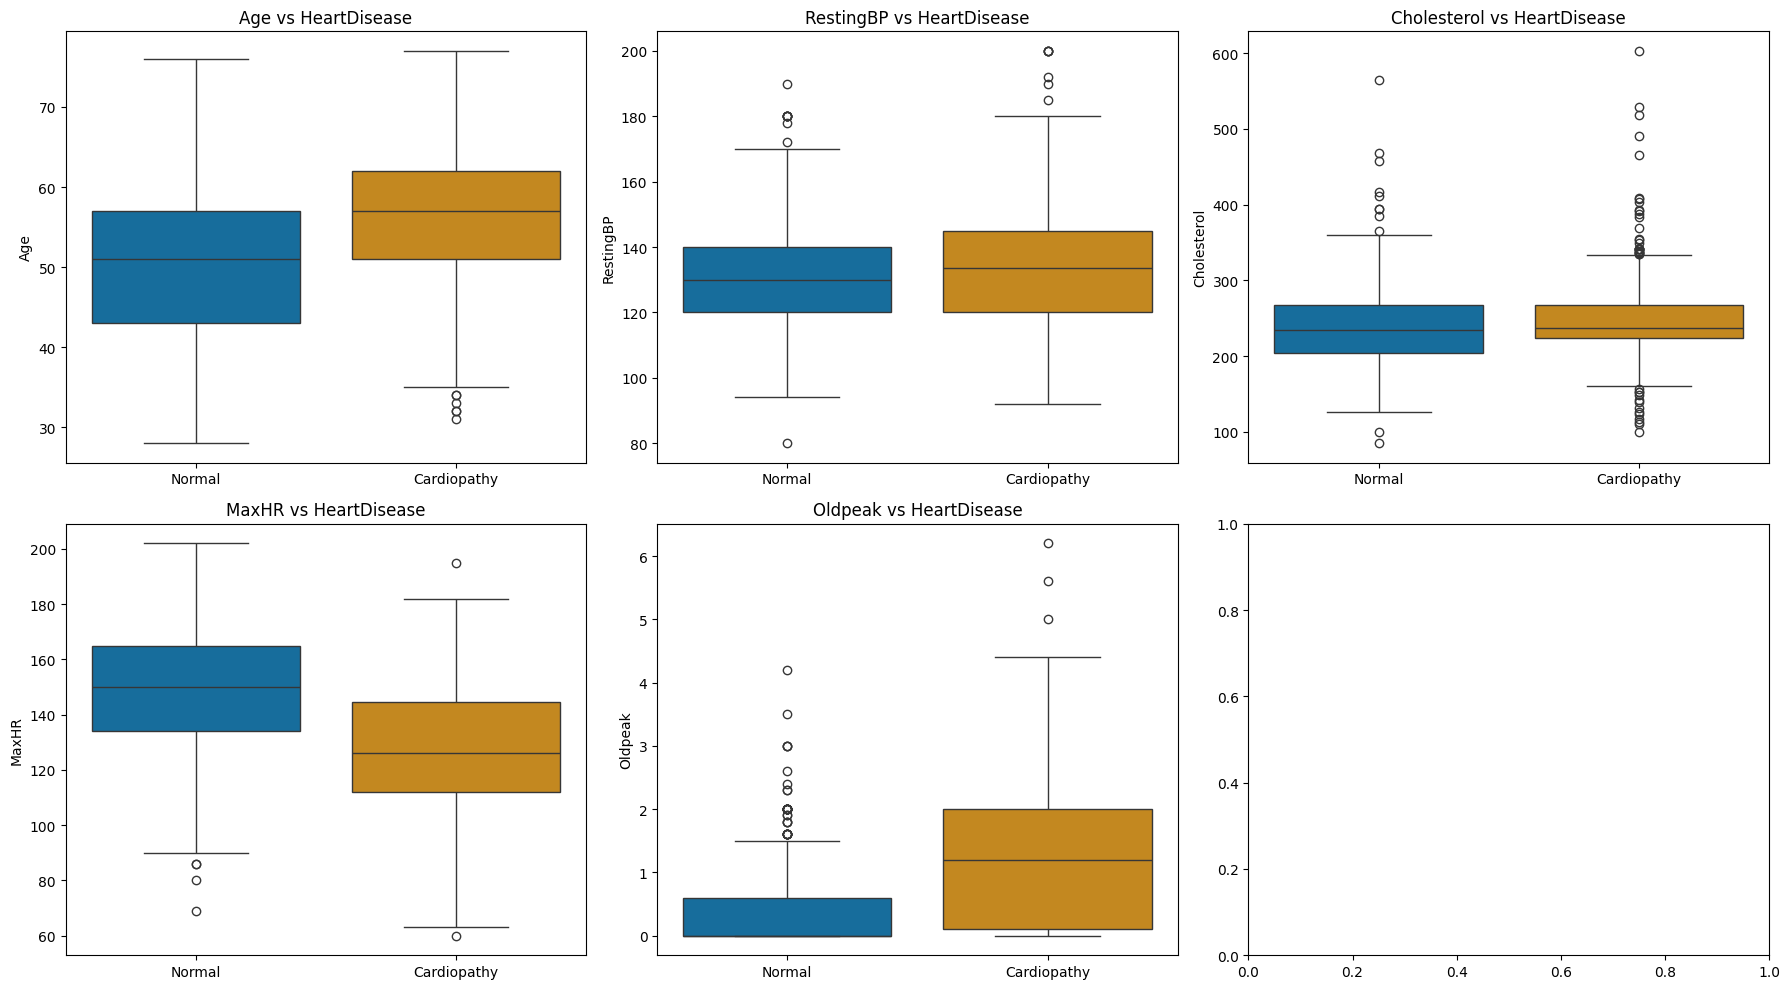

In [63]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x="HeartDisease_label", 
                y=col, 
                data=df,
                ax=axes[i], 
                hue = "HeartDisease_label", 
                palette="colorblind",
                legend=False)
    axes[i].set(xlabel=None)
    axes[i].set_title(f"{col} vs HeartDisease")

plt.tight_layout()
plt.show()

- *Age* shows a noticeable shift between classes, with patients with heart disease presenting a higher median age. Although there is a clear tendency for higher ages to be associated with the presence of heart disease, there is still significant overlap between the two groups, particularly in the 50–55 age range. This indicates that while age is an important factor, it is not sufficient on its own to discriminate between patients with and without heart disease. Additionally, the presence of younger individuals with heart disease suggests that other variables also play a key role in risk prediction.
- *RestingBP* shows very similar distributions across both classes, with strong overlap and nearly identical medians. This suggests limited discriminatory power for this variable in isolation.
- *Cholesterol* exhibits high variability and substantial overlap between classes, limiting its ability to clearly distinguish between patients with and without heart disease. Although numerous outliers are present in both groups, these do not appear to contribute to class separation, suggesting that this variable may have limited predictive value in isolation.
- *MaxHR* shows a noticeable shift between classes, with lower maximum heart rates observed in patients with heart disease. Despite this trend, there is considerable overlap in the range of approximately 115–140 bpm, indicating that while MaxHR is informative, it is not sufficient as a standalone predictor.
- *Oldpeak* shows the strongest separation between classes, with higher values predominantly associated with patients with heart disease. However, some overlap remains, indicating that although Oldpeak is a highly informative variable, it should be considered alongside other features for accurate prediction. 

### Summary of Numerical Variables

- *Oldpeak* and *MaxHR* demonstrate the strongest discriminatory patterns between classes.
- *Age* also shows relevant differences, although with moderate overlap.
- *RestingBP* and *Cholesterol* exhibit limited separation and are less likely to contribute significantly as standalone predictors.

These findings suggest that variables related to cardiovascular stress and performance may play a more important role in predicting heart disease than baseline measurements such as resting blood pressure or cholesterol levels.

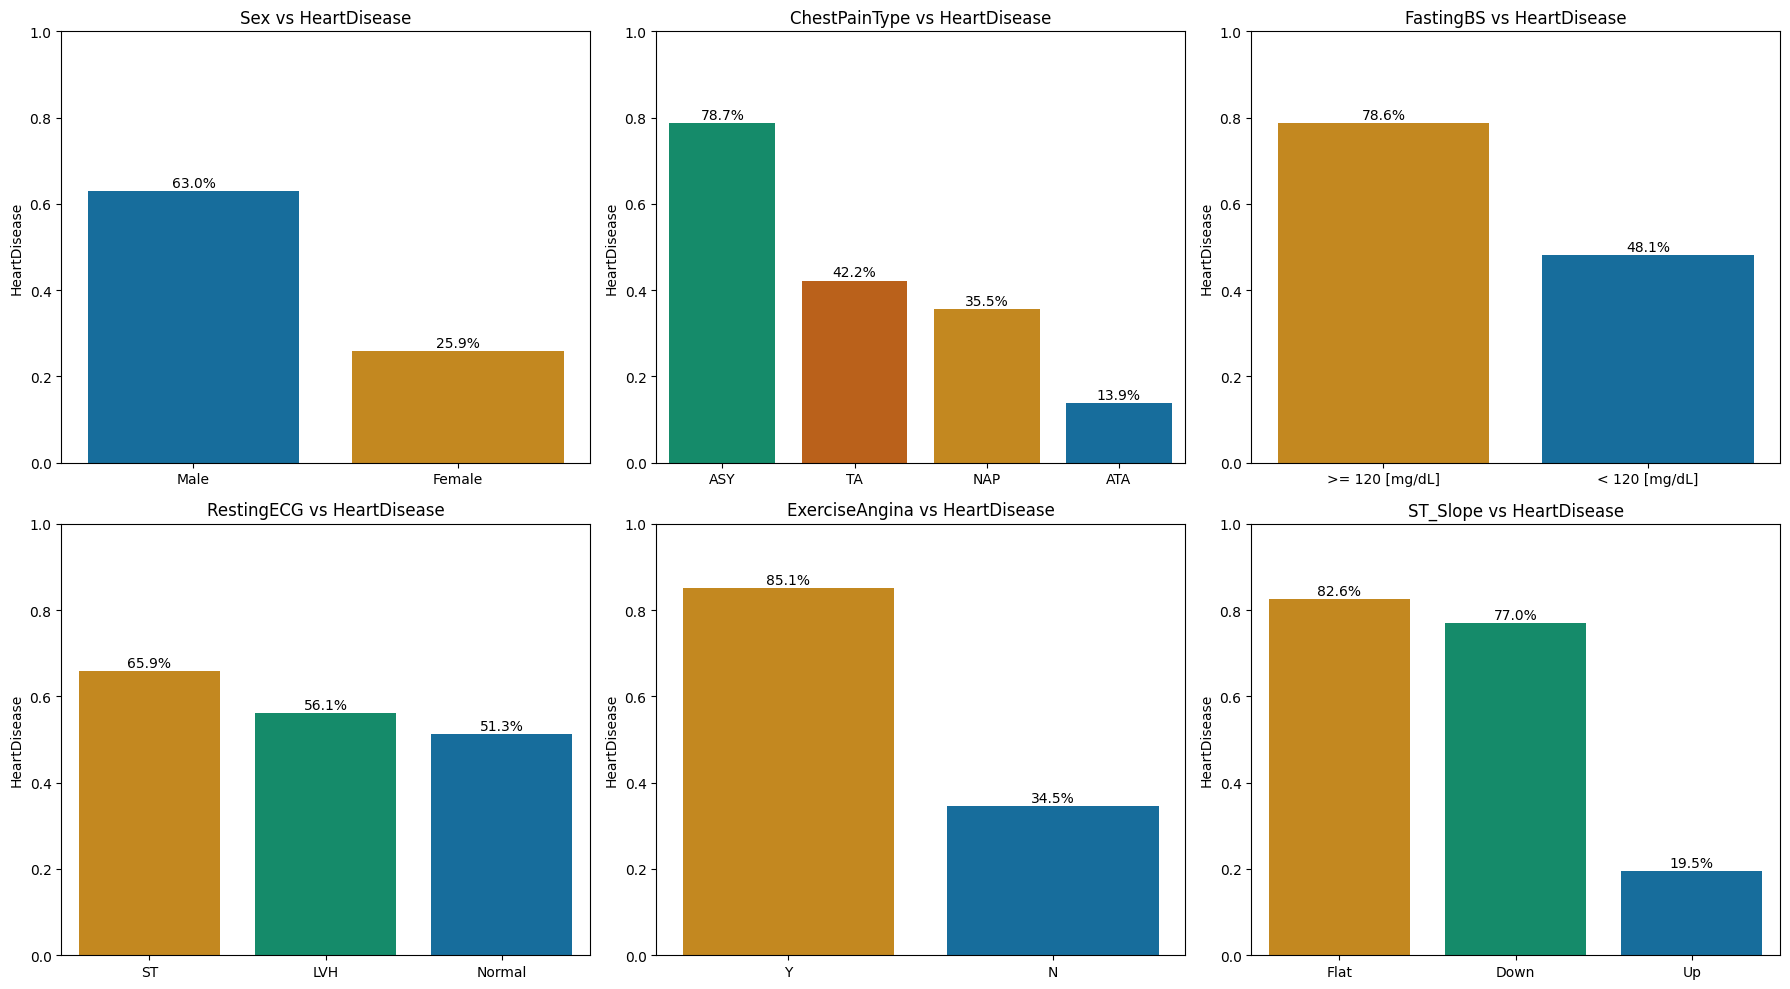

In [73]:
cat_cols = ["Sex", "ChestPainType", "FastingBS",
            "RestingECG", "ExerciseAngina", "ST_Slope"]

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df.groupby(col)["HeartDisease"].mean().sort_values(ascending=False).index
    sns.barplot(x=col, 
                y="HeartDisease", 
                data=df,
                ax=axes[i], 
                hue=col, 
                palette="colorblind",
                legend=False,
                order=order,
                errorbar=None)
    axes[i].set(xlabel=None)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f"{col} vs HeartDisease")
    for p in axes[i].patches:
        height = p.get_height()
        axes[i].text(
            p.get_x() + p.get_width() / 2,
            height + 0.01,
            f"{height*100:.1f}%",
            ha="center"
        )

plt.tight_layout()
plt.show()

- Male patients show a higher proportion of heart disease compared to females, suggesting a potential *sex*-related risk factor.
- *ChestPainType* shows strong differentiation across categories. Asymptomatic patients (ASY) present the highest probability of heart disease, while other categories show significantly lower risk levels. This suggests that chest pain characteristics are highly informative for prediction.
- *RestingECG* shows some variation across categories, but with less pronounced differences compared to other variables, suggesting a more limited predictive contribution.
- Patients with *exercise-induced angina* show a markedly higher probability of heart disease, indicating a strong association with cardiovascular risk.
- *ST_Slope* demonstrates a clear pattern, with flat or downsloping ST segments associated with a higher likelihood of heart disease. This variable appears to be one of the strongest categorical predictors.
- Patients with elevated *fasting blood sugar* (FastingBS >= 120 [mg/dL]) show a higher probability of heart disease compared to those with normal levels. This suggests that impaired glucose regulation may be associated with increased cardiovascular risk.

### Summary of Categorical Variables

- *ChestPainType*, *ExerciseAngina*, *ST-Slope* and *FastingBS* demonstrate the strongest discriminatory patterns between classes.
- *Sex* and *RestingECG* show weaker or more moderate relationships

## Correlation

## Feature engineering

In [74]:
df.drop(columns="HeartDisease_label", inplace=True)

In [75]:
# Encoding
binary_cols = ["Sex", "ExerciseAngina", "FastingBS"]
for bin in binary_cols:
    df[bin] = df[bin].map({"Male":1, "Female":0}) if bin=="Sex" else (df[bin].map({"Y":1, "N":0}) if bin=="ExerciseAngina" else df[bin].map({">= 120 [mg/dL]":1, "< 120 [mg/dL]":0}))

noBinary_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
df = pd.get_dummies(df, columns=noBinary_cols, drop_first=True)

# Convert bool to int
dummy_cols = df.select_dtypes(include="bool").columns
df[dummy_cols] = df[dummy_cols].astype(int)
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160.0,180.0,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,0,0,1,0,1,0,0,1


Categorical variables were encoded using one-hot encoding. Resulting boolean features were converted to integer format (0/1) for compatibility and interpretability.

## Model

## Evaluation

## Conclusions

- Introducción 1
- Carga de datos 1
- Limpieza 1
- EDA univariado 1
- EDA bivariado 0
- Correlación 0
- Feature engineering 0
- Modelado 0
- Evaluación 0
- Conclusiones 0